In [79]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from skimage import io, color
from sklearn.linear_model import OrthogonalMatchingPursuit
import os
import time
import random

In [80]:
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'D_learned'])


In [81]:
data = loadmat('/Users/drishtant/Desktop/CS754 Project/AIP_26 Course Project l_1-2/drishtant/data/learned_dictionary_bsds500.mat')
D = data['D_learned']  # shape (n_features, n_atoms)

print("Dictionary shape:", D.shape)

Dictionary shape: (64, 256)


In [82]:
def load_image(path):
    img = io.imread(path)

    if len(img.shape) == 3:
        img = color.rgb2gray(img)

    img = img.astype(np.float32)

    # Normalize safely
    if img.max() > 1:
        img = img / 255.0
    else:
        img = img / img.max()

    return img

In [83]:
def add_noise(img, sigma=0.1):
    noisy = img + sigma * np.random.randn(*img.shape)
    return np.clip(noisy, 0, 1)

In [84]:
def extract_patches(img, patch_size=8):
    patches = []
    means = []

    h, w = img.shape

    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = img[i:i+patch_size, j:j+patch_size]
            m = np.mean(patch)

            patches.append((patch - m).flatten())
            means.append(m)

    return np.array(patches), np.array(means)


def reconstruct_image(patches, means, img_shape, patch_size=8):
    h, w = img_shape
    img = np.zeros(img_shape)
    idx = 0

    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = patches[idx].reshape(patch_size, patch_size)
            img[i:i+patch_size, j:j+patch_size] = patch + means[idx]
            idx += 1

    return img

In [85]:
def psnr(img1, img2):
    mse = np.mean((img1 - img2)**2)
    return 10 * np.log10(1.0 / mse)

def rmse(img1, img2):
    return np.sqrt(np.mean((img1 - img2)**2))

In [86]:
def omp_denoise(img, D, sigma=0.1, sparsity=10):

    noisy = add_noise(img, sigma)

    patches, means = extract_patches(noisy)

    omp = OrthogonalMatchingPursuit(n_nonzero_coefs=sparsity)

    start = time.time()

    X = []
    for p in patches:
        omp.fit(D, p)
        X.append(omp.coef_)

    X = np.array(X)

    reconstructed = np.dot(X, D.T)

    denoised = reconstruct_image(reconstructed, means, img.shape)

    elapsed = time.time() - start

    return noisy, denoised, elapsed

In [87]:
img_path = '/Users/drishtant/Desktop/CS754 Project/AIP_26 Course Project l_1-2/datasets/BSDS500/images/test/130014.jpg'

img = load_image(img_path)

noisy, denoised, t = omp_denoise(img, D)

print("PSNR:", psnr(img, denoised))
print("RMSE:", rmse(img, denoised))
print("Time:", t)

PSNR: 20.816129114796382
RMSE: 0.0910318867789253
Time: 2.5918140411376953


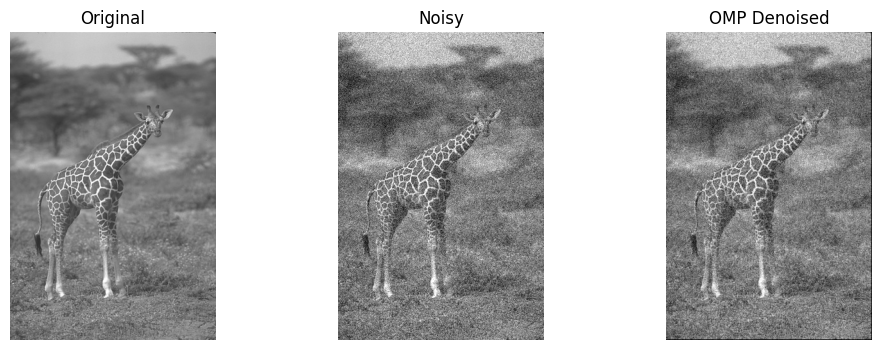

In [88]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(noisy, cmap='gray', vmin=0, vmax=1)
plt.title("Noisy")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(denoised, cmap='gray', vmin=0, vmax=1)
plt.title("OMP Denoised")
plt.axis('off')

plt.show()

In [89]:
dataset_path = "/Users/drishtant/Desktop/CS754 Project/AIP_26 Course Project l_1-2/datasets/BSDS500/images/test"

image_files = [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if f.endswith('.jpg')]

random.shuffle(image_files)
selected_images = image_files[:20]

In [90]:
psnr_list = []
rmse_list = []
time_list = []

for img_path in selected_images:

    img = load_image(img_path)

    noisy, denoised, t = omp_denoise(img, D)

    psnr_list.append(psnr(img, denoised))
    rmse_list.append(rmse(img, denoised))
    time_list.append(t)

    print(f"{os.path.basename(img_path)} → PSNR: {psnr_list[-1]:.2f}")

97010.jpg → PSNR: 19.92
228076.jpg → PSNR: 21.48
41096.jpg → PSNR: 20.95
17067.jpg → PSNR: 20.62
232076.jpg → PSNR: 21.04
80085.jpg → PSNR: 21.39
70090.jpg → PSNR: 21.62
253016.jpg → PSNR: 20.51
223004.jpg → PSNR: 21.01
281017.jpg → PSNR: 21.05
226060.jpg → PSNR: 21.39
130066.jpg → PSNR: 20.52
393035.jpg → PSNR: 21.02
258089.jpg → PSNR: 21.33
117025.jpg → PSNR: 20.27
107014.jpg → PSNR: 20.78
106005.jpg → PSNR: 21.36
123057.jpg → PSNR: 20.97
48017.jpg → PSNR: 21.14
161045.jpg → PSNR: 20.92


In [91]:
print("\n===== OMP FINAL RESULTS =====")
print("Average PSNR:", np.mean(psnr_list))
print("Average RMSE:", np.mean(rmse_list))
print("Average Time:", np.mean(time_list))


===== OMP FINAL RESULTS =====
Average PSNR: 20.963852986982438
Average RMSE: 0.08960276857539251
Average Time: 2.4441611051559446
